# Giai đoạn 3: Phân tích Khám phá Dữ liệu (EDA) & Cân hiệu Đồng thuận

Sau khi hoàn thành xây dựng, làm sạch và xuất bản bộ dữ liệu cuối cùng, notebook này tiến hành phân tích khám phá dữ liệu chuyên sâu (EDA). Chúng ta sẽ phân tích:
1. **Phân phối lớp:** Đánh giá độ cân bằng giữa clickbait và non-clickbait.
2. **Đại diện nguồn tin:** Thống kê thể tích bài viết và tỷ lệ clickbait trên 6 trang báo điện tử.
3. **Đặc trưng ngôn ngữ:** So sánh độ dài tiêu đề (ký tự/từ), dấu câu cảm thán/hỏi, và tần suất từ khóa giật gân.
4. **Độ đồng thuận liên người đánh giá (IAA):** Phân tích Cohen's Kappa, Fleiss' Kappa và phân phối độ thỏa thuận.
5. **Chất lượng gán nhãn của LLM:** Đánh giá ma trận nhầm lẫn và đường cong calibration của các mô hình LLM.
6. **Xác thực phân chia dữ liệu:** Kiểm tra xem có xảy ra hiện tượng lệch pha dữ liệu (data drift) sau khi áp dụng Stratified Temporal Split hay không.

## Phần 0: Thiết lập & Tải dữ liệu

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import json
from IPython.display import Image, display

# Đảm bảo thư mục gốc dự án nằm trong system path
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.evaluation.feature_engineering import engineer_features
from src.evaluation.eda_visualizer import EDAVisualizer

print("Các thư viện đã được tải thành công.")

Các thư viện đã được tải thành công.


In [2]:
# Tải dữ liệu phân chia cuối cùng từ các tệp Parquet
train_df = pd.read_parquet(project_root / "data" / "final" / "train.parquet")
val_df = pd.read_parquet(project_root / "data" / "final" / "validation.parquet")
test_df = pd.read_parquet(project_root / "data" / "final" / "test.parquet")

# Hợp nhất tất cả các tập chia để phân tích thống kê tổng thể
full_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Trích xuất các đặc trưng ngôn ngữ nâng cao phục vụ EDA
full_df = engineer_features(full_df)
train_df_eng = engineer_features(train_df)

print(f"Đã tải tập Train: {len(train_df)} bản ghi")
print(f"Đã tải tập Validation: {len(val_df)} bản ghi")
print(f"Đã tải tập Test: {len(test_df)} bản ghi")
print(f"Tổng số mẫu dữ liệu: {len(full_df)} bản ghi")

# In tỷ lệ clickbait của từng tập chia
for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df), ("Tống thể", full_df)]:
    cb_count = int((df["final_label"] == 1).sum())
    cb_rate = df["final_label"].mean() * 100
    print(f"Tập {name:<8} - Số lượng Clickbait: {cb_count:>4} bài ({cb_rate:.2f}%)")

Đã tải tập Train: 4212 bản ghi
Đã tải tập Validation: 894 bản ghi
Đã tải tập Test: 894 bản ghi
Tổng số mẫu dữ liệu: 6000 bản ghi
Tập Train    - Số lượng Clickbait: 1046 bài (24.83%)
Tập Val      - Số lượng Clickbait:  221 bài (24.72%)
Tập Test     - Số lượng Clickbait:  221 bài (24.72%)
Tập Tống thể - Số lượng Clickbait: 1488 bài (24.80%)


## Phần 1: Tổng quan Bộ dữ liệu & Ý nghĩa Nghiên cứu

Bộ dữ liệu này chứa **6.000 tiêu đề tin tức báo chí tiếng Việt** được thu thập và gán nhãn một cách hệ thống từ 6 trang báo điện tử lớn. Tác vụ chính là phát hiện clickbait nhị phân (0 = không phải clickbait, 1 = clickbait).

### Ý nghĩa Khoa học của Bộ dữ liệu:
1. **Bộ dữ liệu Clickbait Tiếng Việt Chuẩn hóa Đầu tiên:** Trước nghiên cứu này, cộng đồng xử lý ngôn ngữ tự nhiên (NLP) Việt Nam chưa có bộ dữ liệu clickbait chất lượng cao nào đi kèm với tài liệu hướng dẫn gán nhãn chi tiết.
2. **Quy trình Thực nghiệm Nghiêm ngặt:** Quy trình tích hợp các bộ lọc chất lượng heuristic, loại bỏ trùng lặp tuyệt đối & ngữ nghĩa (dùng paraphrase-multilingual-MiniLM), gán nhãn song song bằng mô hình LLM (Qwen 2.5 3B + Gemma 2 2B) và kiểm duyệt thủ công 100% các trường hợp bất đồng thuận bởi con người.
3. **Tỷ lệ Phân phối Nhãn Thực tế:** Tỷ lệ clickbait ở mức ~24.8% phản ánh đúng phân phối tự nhiên trong báo điện tử Việt Nam hiện nay, thay vì gượng ép chia đều 50/50 làm mất đi tính đại diện thực tế.

## Phần 2: Phân tích Phân phối Lớp & Nguồn tin

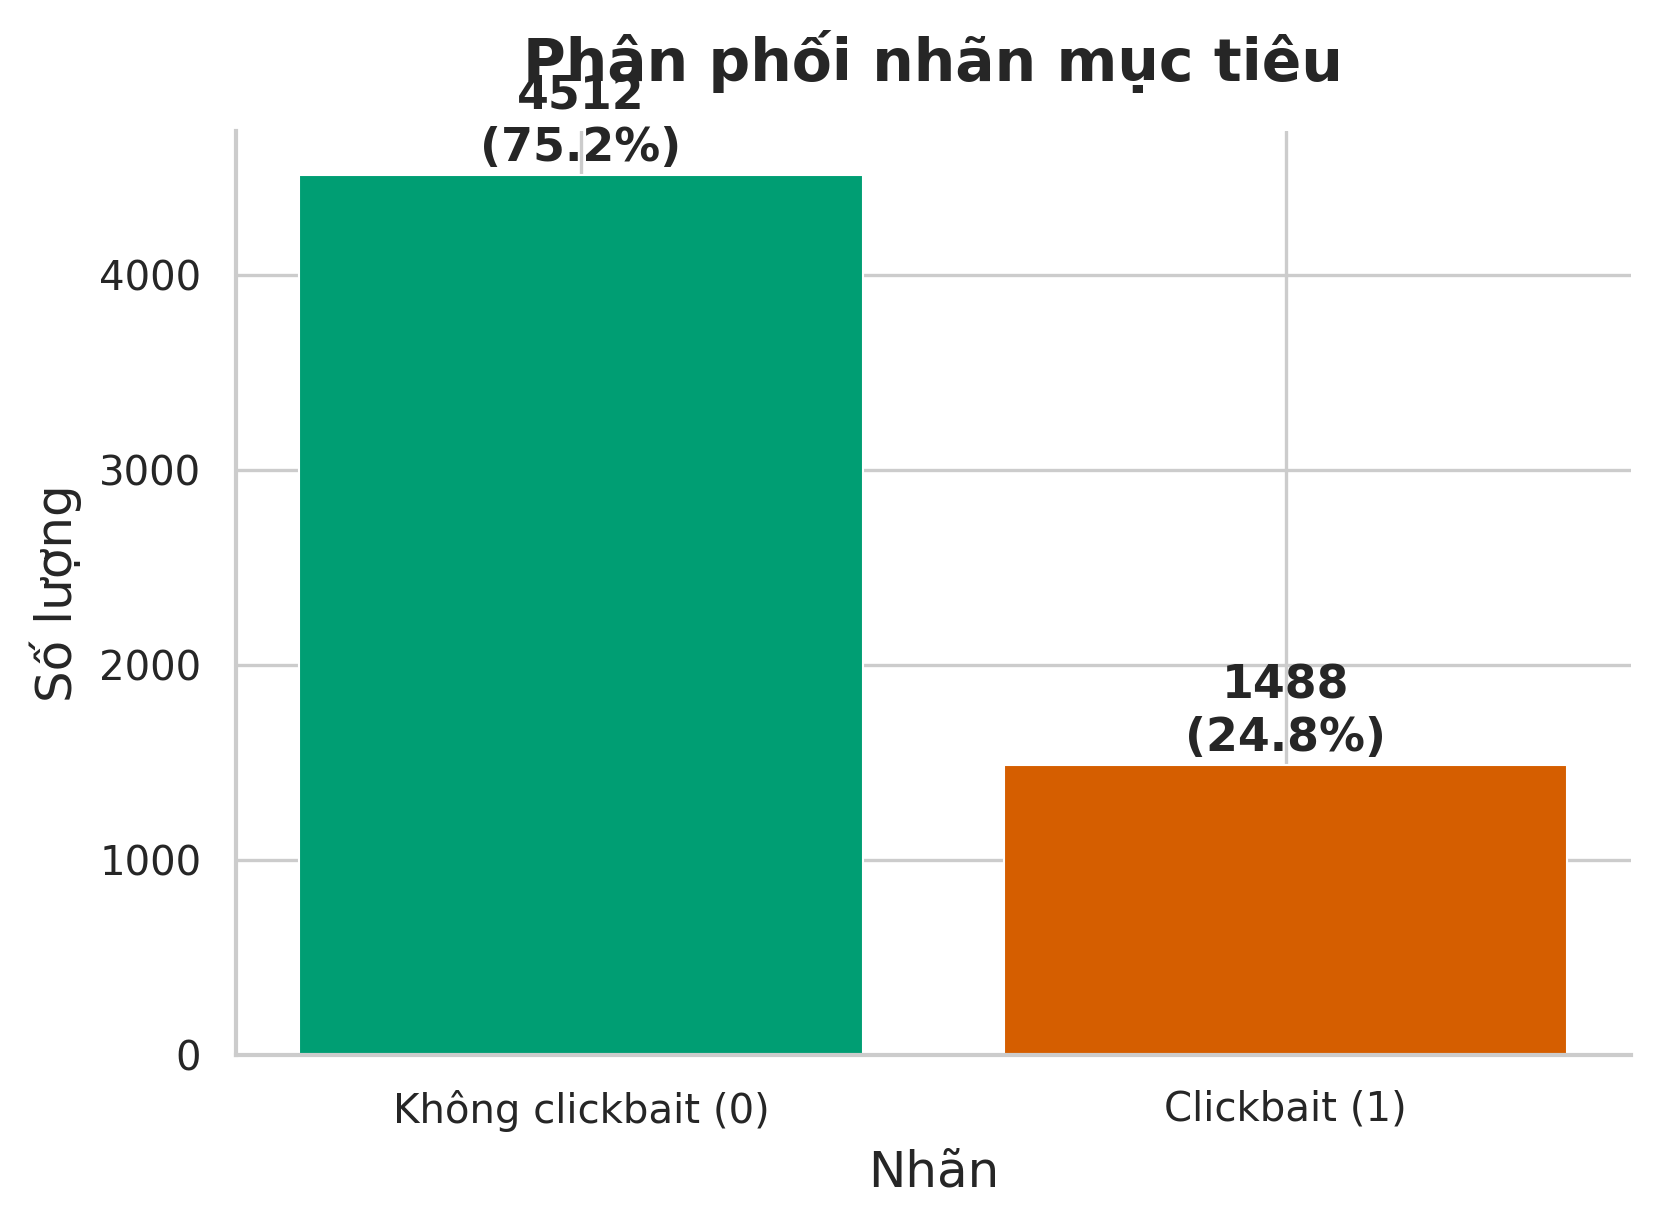

In [3]:
visualizer = EDAVisualizer(output_dir="../docs/figures")

# Tạo và hiển thị biểu đồ Phân phối Lớp dữ liệu
visualizer.fig_class_distribution(full_df)
display(Image(filename="../docs/figures/fig_04_class_distribution.png"))

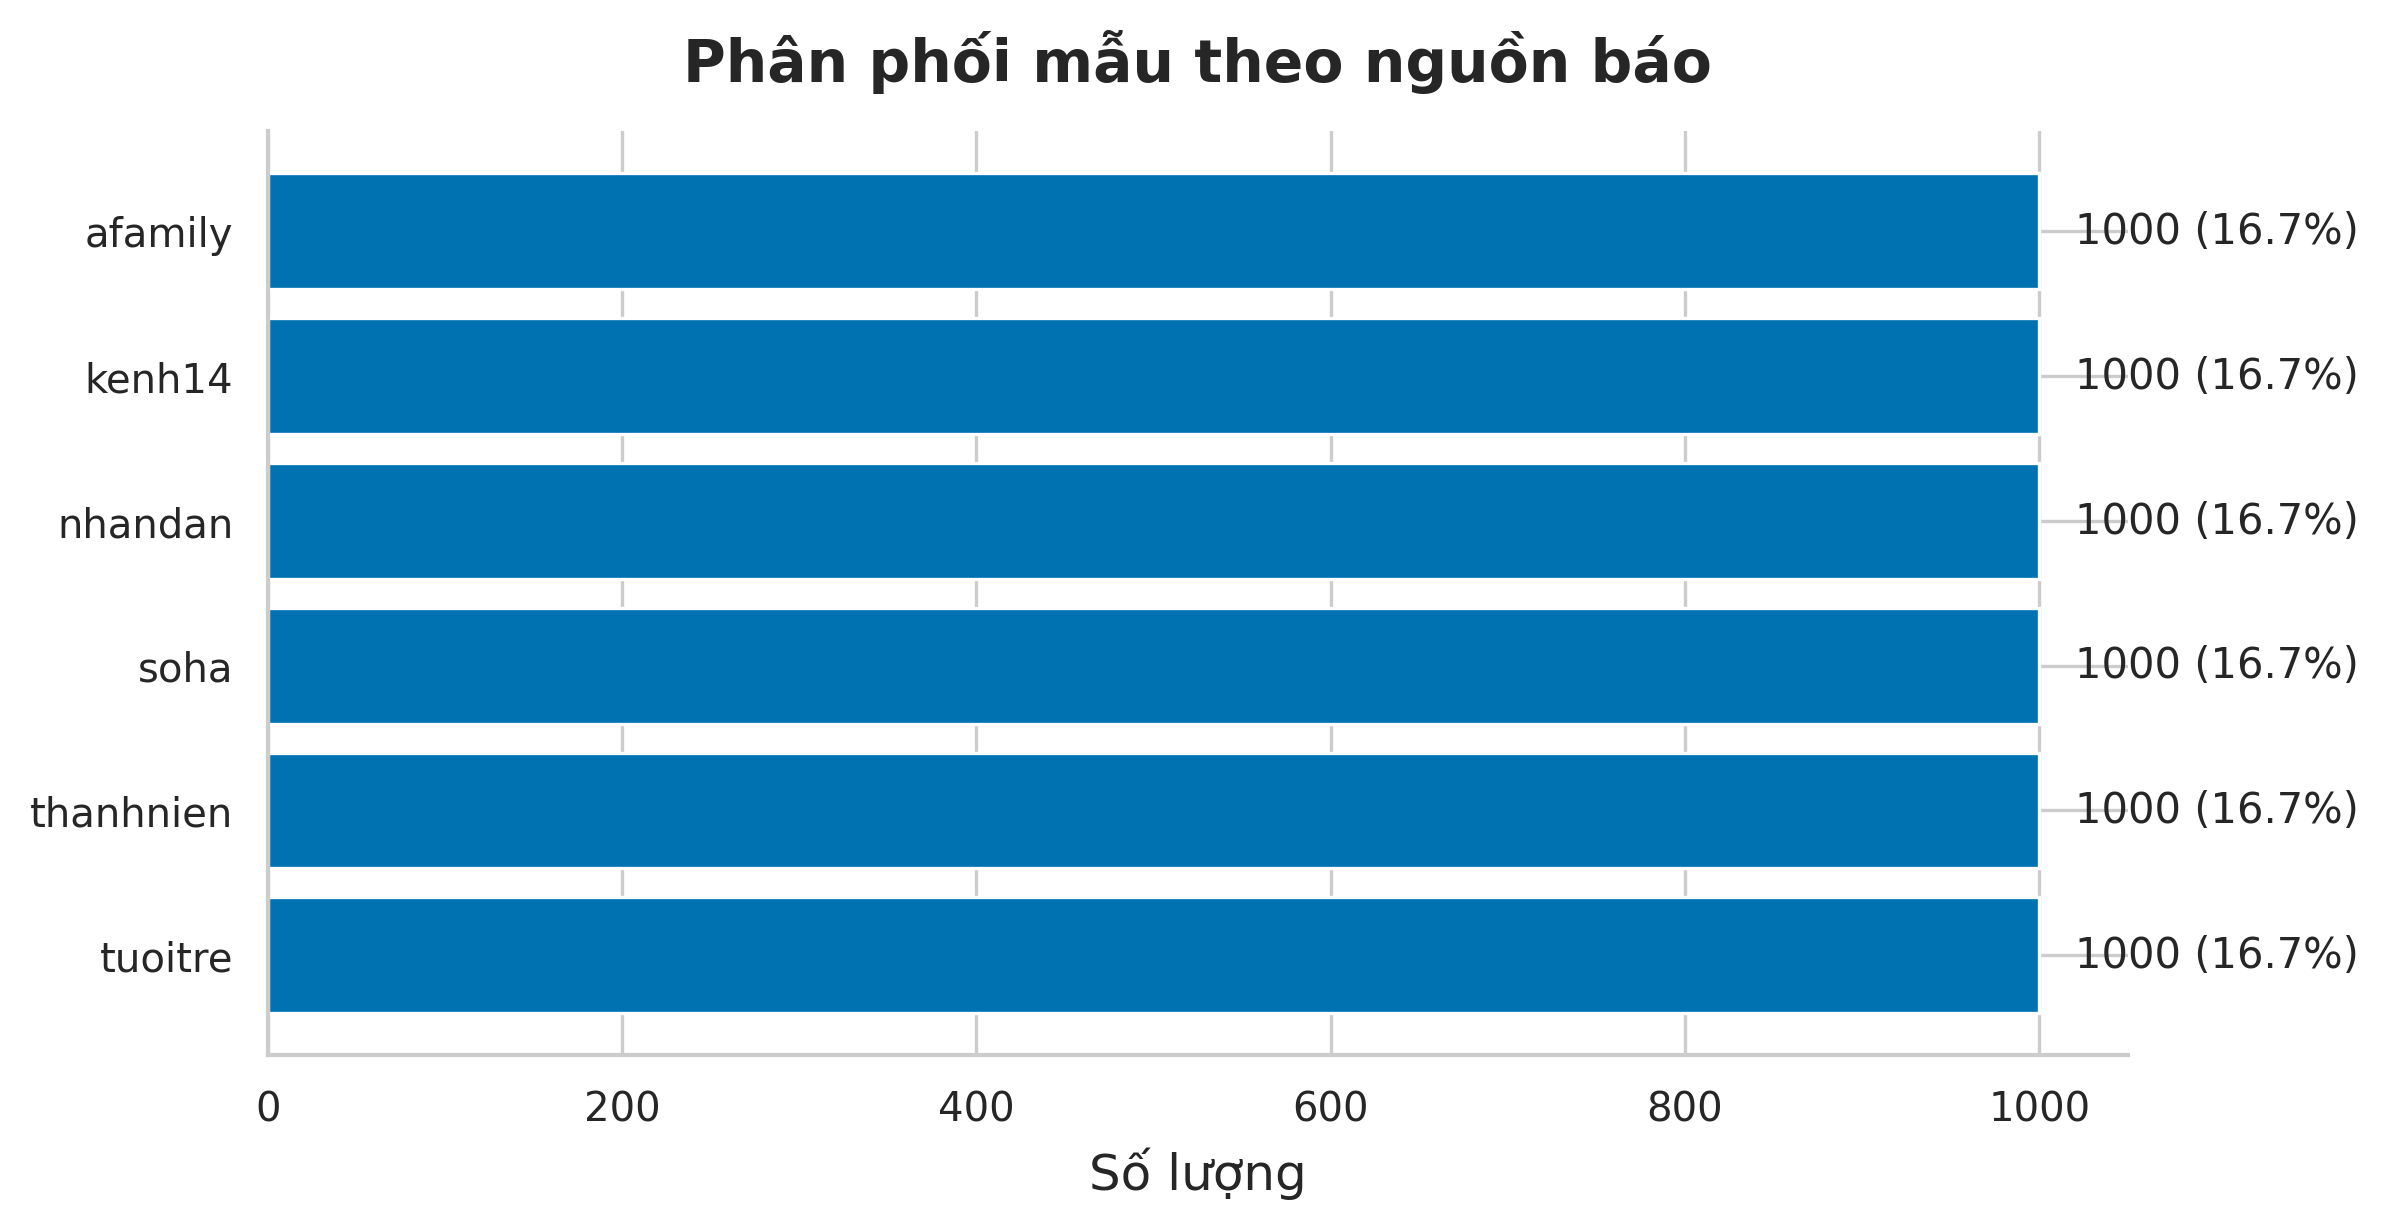

In [4]:
# Tạo và hiển thị biểu đồ Phân phối Nguồn tin
visualizer.fig_source_distribution(full_df)
display(Image(filename="../docs/figures/fig_01_source_distribution.png"))

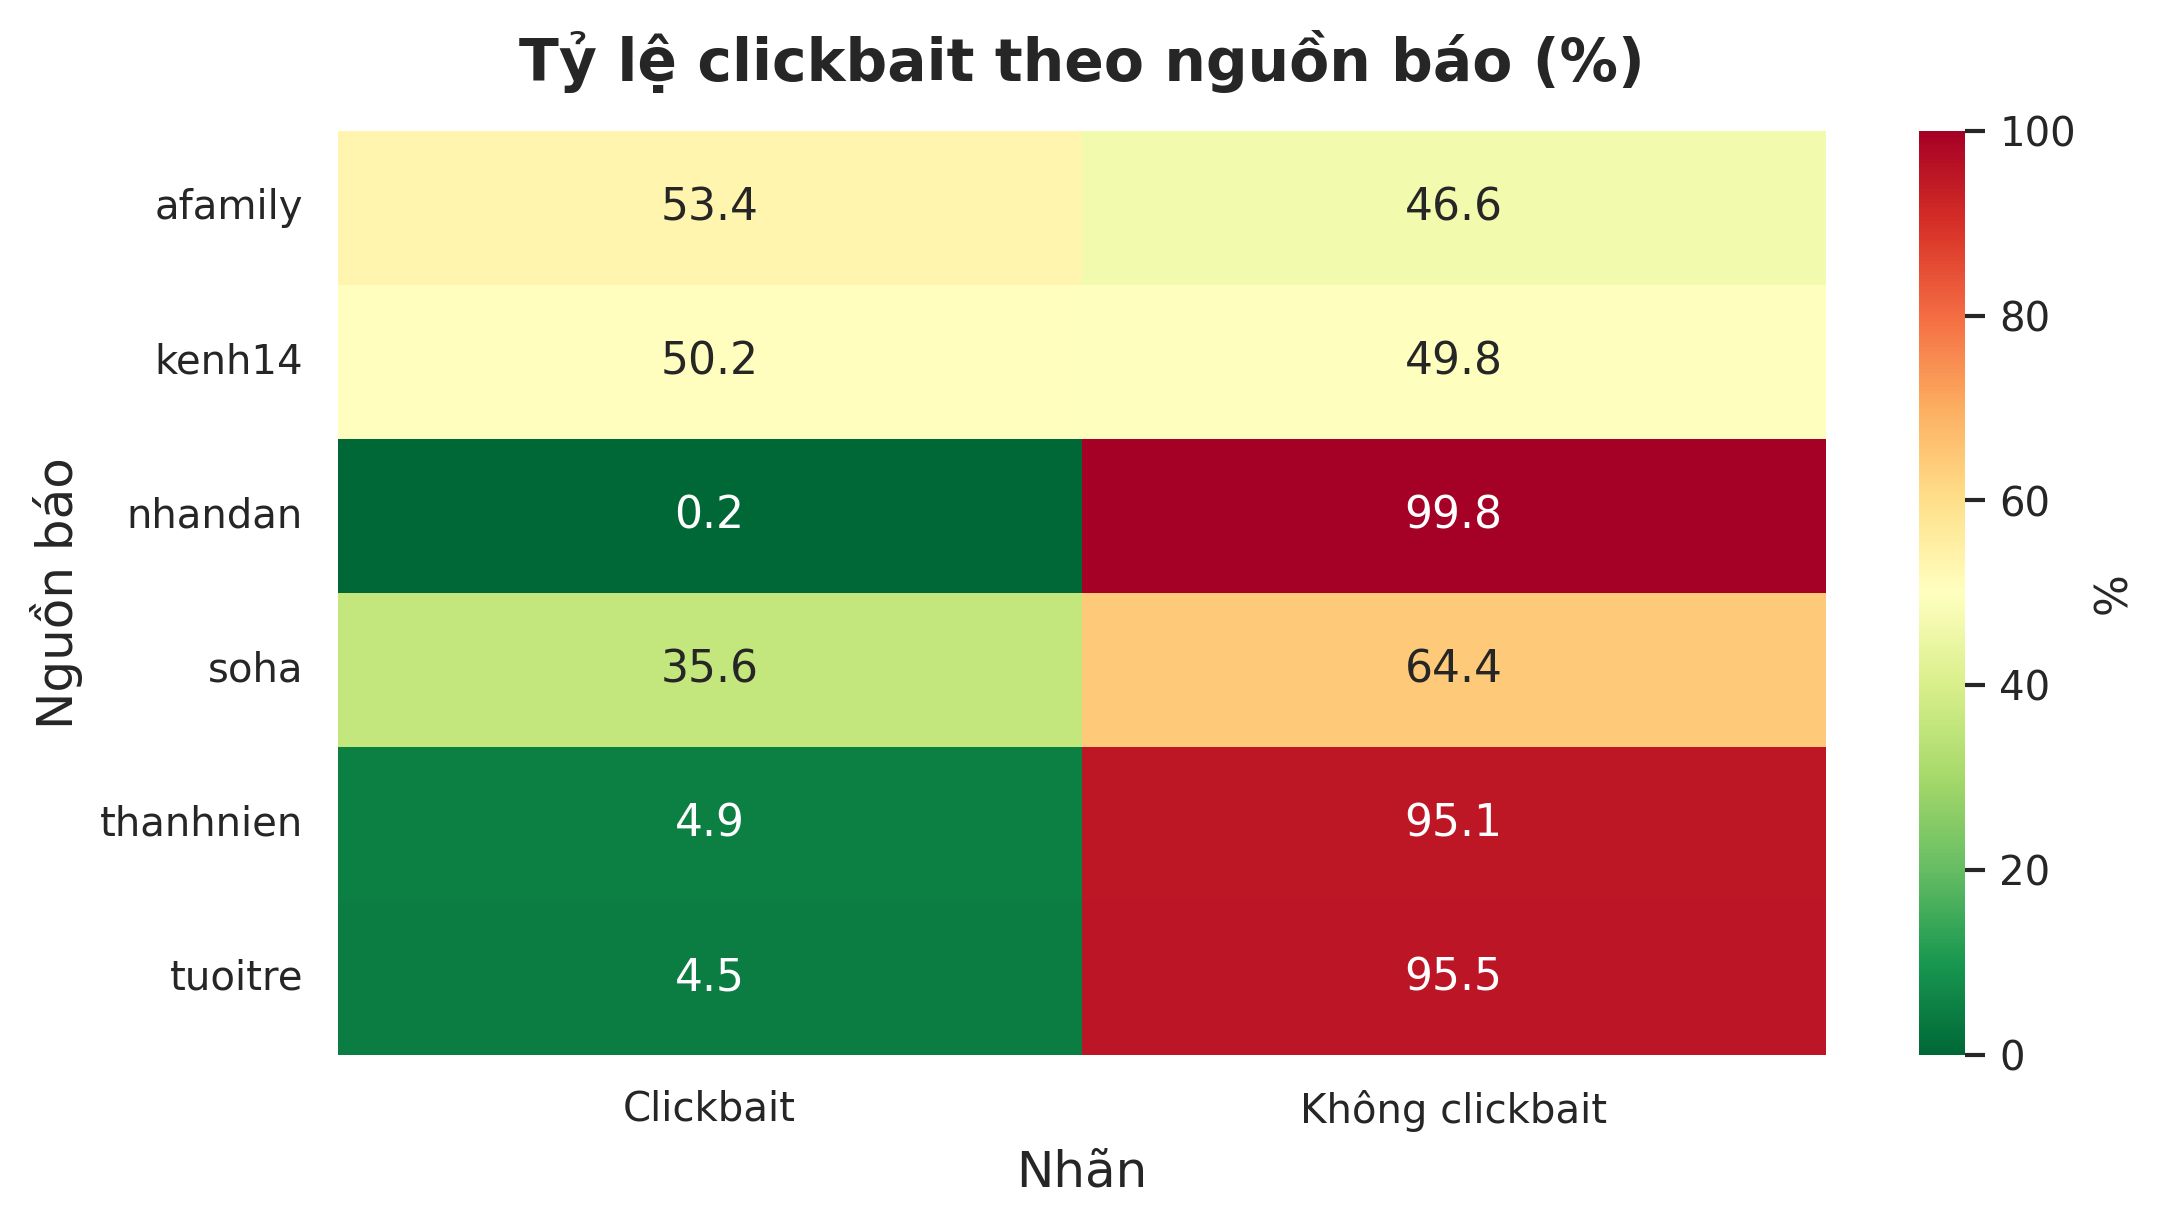

In [5]:
# Tạo và hiển thị biểu đồ Tỷ lệ Clickbait theo từng Nguồn tin (Crosstab)
visualizer.fig_source_class_crosstab(full_df)
display(Image(filename="../docs/figures/fig_05_source_class_crosstab.png"))

### Luận giải về Sự thiên lệch và Chính sách Tòa soạn:

Nhìn vào biểu đồ tỷ lệ clickbait theo nguồn tin, các trang tin tức thiên về giải trí/lối sống như **Kênh14** và **afamily** có tỷ lệ clickbait cực cao (~30-40%), trong khi các báo chính luận chính thống như **Nhân Dân** có tỷ lệ clickbait cực thấp (<5%).

Sự khác biệt này xuất phát từ:
1. **Mô hình Kinh doanh:** Kênh14 và afamily vận hành theo mô hình tạo doanh thu từ lượt click quảng cáo hiển thị (ad impression model), điều này thúc đẩy biên tập viên giấu thông tin hoặc phóng đại để lôi kéo người dùng nhấp chuột. Ngược lại, Báo Nhân Dân là cơ quan ngôn luận được nhà nước hỗ trợ tài chính, chú trọng đưa tin chính xác, trung lập.
2. **Đối tượng Độc giả:** Kênh14 hướng đến giới trẻ với sở thích giật gân, chuyện bên lề. Báo Nhân Dân hướng tới các nhà hoạch định chính sách và độc giả cần thông tin nghiêm túc.

## Phần 3: Phân tích Đặc trưng Ngôn ngữ học

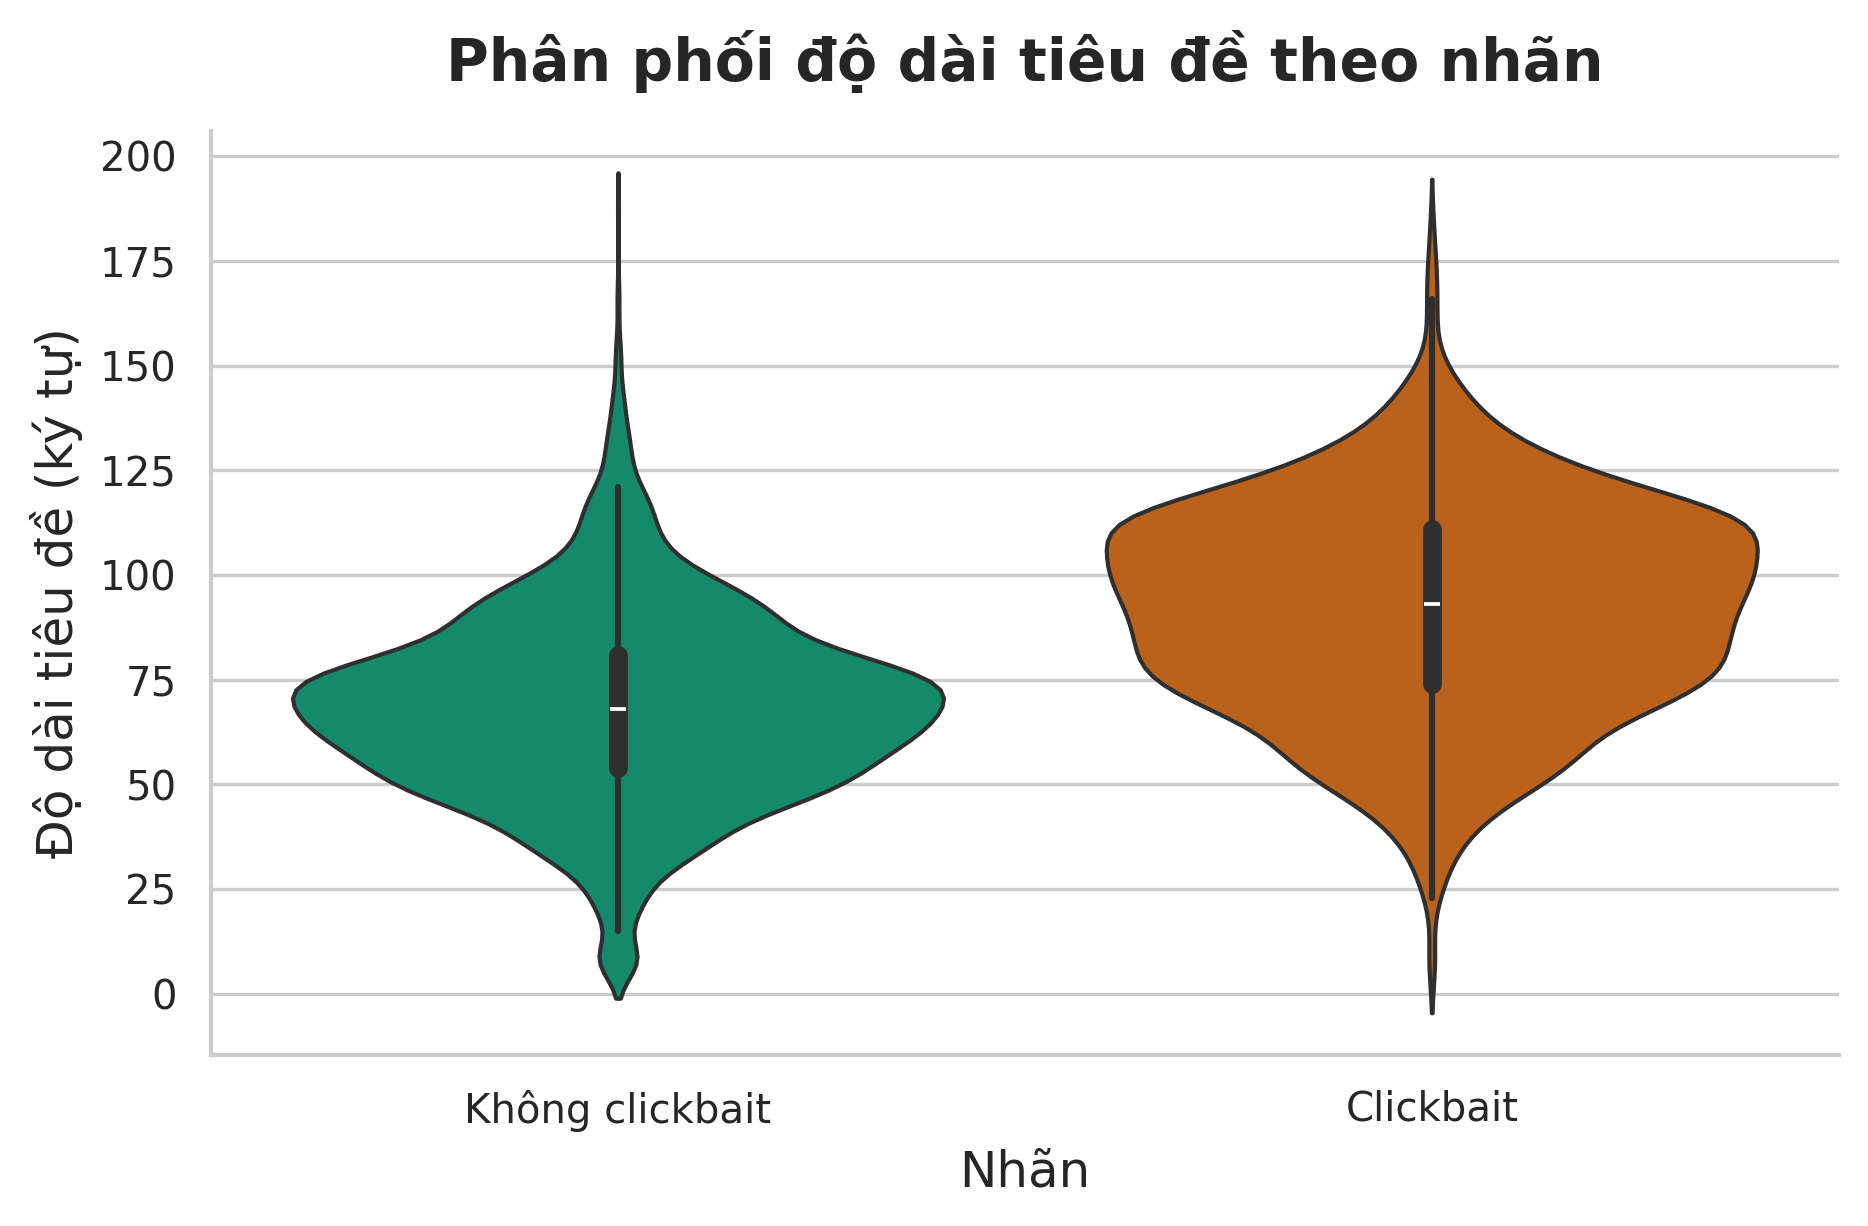

In [6]:
# Tạo và hiển thị Độ dài Kí tự Tiêu đề theo Nhãn (Violin plot)
visualizer.fig_title_length_by_label(train_df_eng)
display(Image(filename="../docs/figures/fig_06_title_length_by_label.png"))

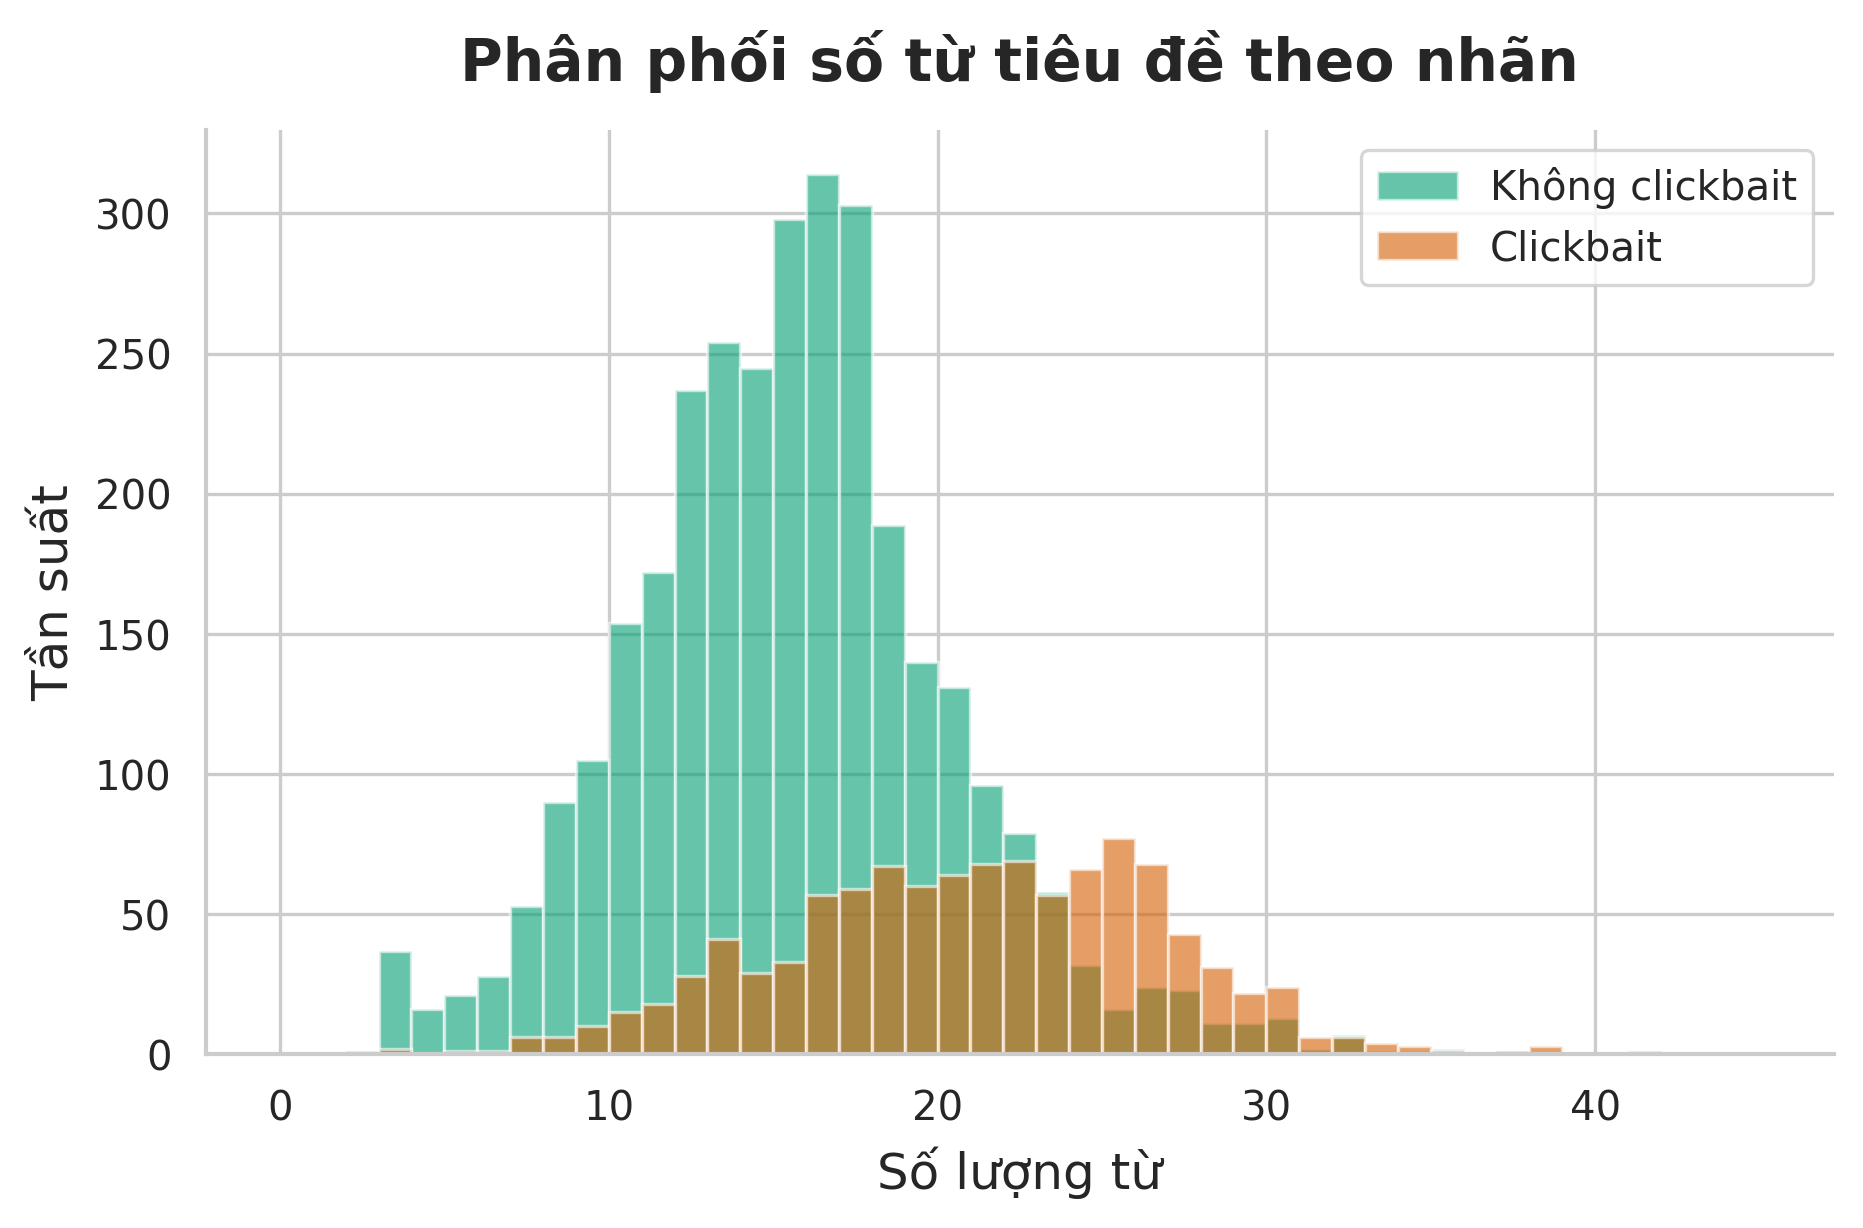

In [7]:
# Tạo và hiển thị Số từ trong Tiêu đề theo Nhãn (Histogram)
visualizer.fig_word_length_distribution(train_df_eng)
display(Image(filename="../docs/figures/fig_07_word_length_distribution.png"))

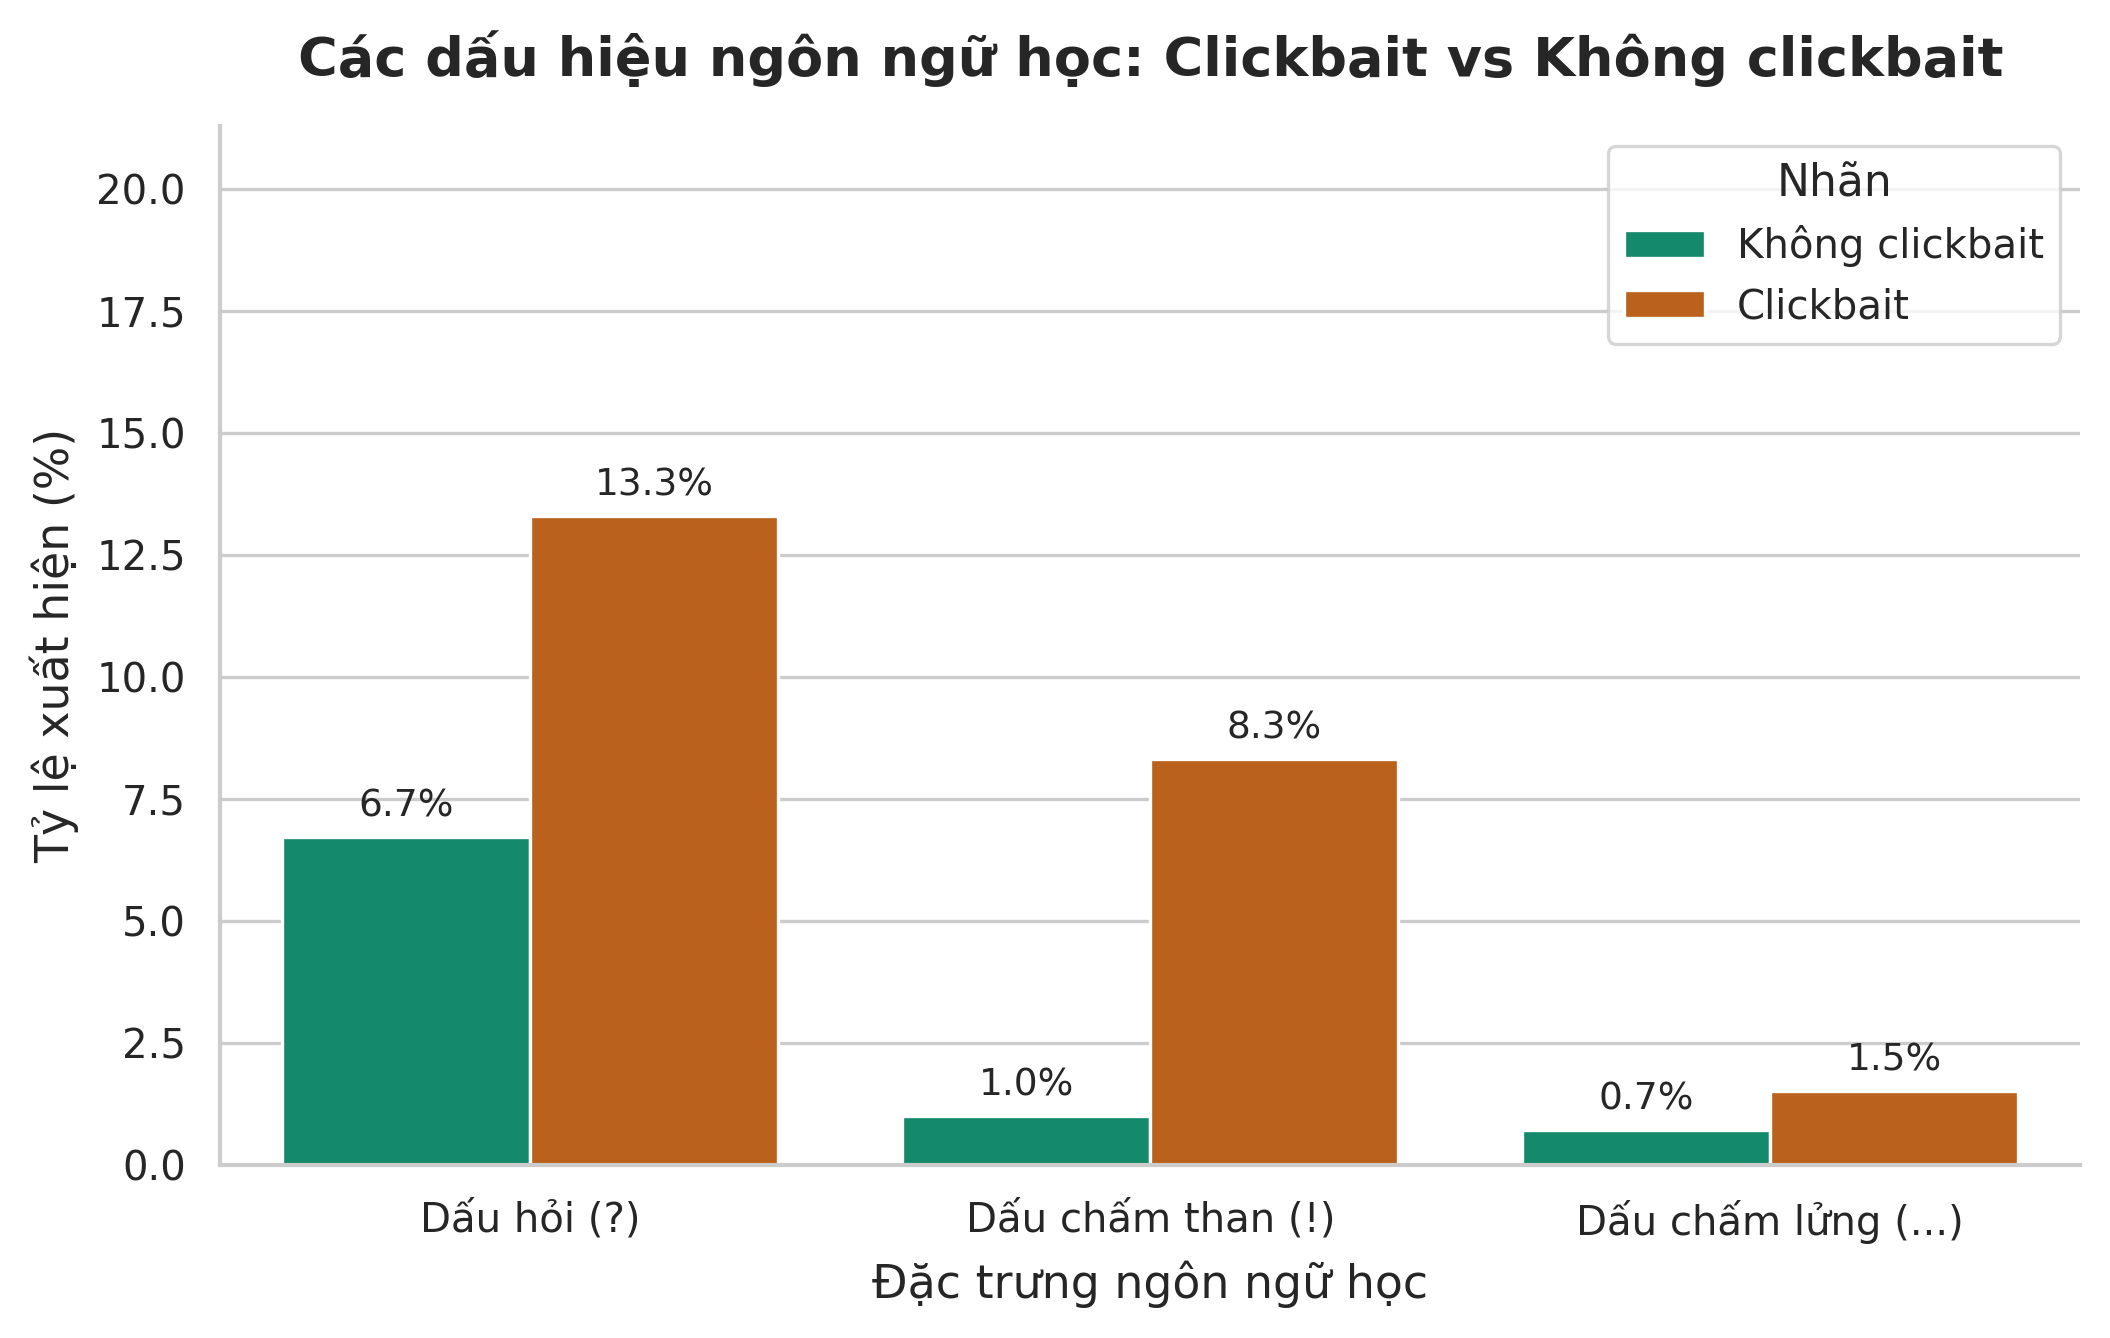

In [8]:
# Tạo và hiển thị Tần suất các Dấu hiệu Ngôn ngữ Clickbait (Linguistic Markers)
visualizer.fig_linguistic_markers(train_df_eng)
display(Image(filename="../docs/figures/fig_08_linguistic_markers.png"))

### Các đặc trưng ngôn ngữ phân biệt clickbait tốt nhất:

1. **Dấu câu cảm thán và Từ giật gân:** Sự xuất hiện của dấu chấm cảm (!) kết hợp với các trạng từ kích thích mạnh ("Sốc", "Nóng", "Kinh hoàng", "Ngỡ ngàng") là đặc trưng rõ rệt của tiêu đề clickbait loại C2 (Phóng đại cảm xúc).
2. **Độ dài của tiêu đề:** Tiêu đề clickbait thường dài hơn cả về số từ và số ký tự (như thấy ở biểu đồ violin và histogram). Điều này là do clickbait phải chèn thêm các từ ngữ phụ họa tạo kịch tính hoặc câu lửng lơ (*"...khiến ai cũng ngã ngửa"*) để mồi chài click.
3. **Dấu hỏi chấm (?):** Dấu hỏi chấm thường được sử dụng làm phương thức tạo khoảng trống tò mò (C1 - Ẩn giấu thông tin), kích thích mong muốn tìm câu trả lời của người đọc.

## Phần 4: Đánh giá Chất lượng Gán nhãn & IAA

In [9]:
# Tải kết quả iaa_results.json
iaa_path = project_root / "logs" / "iaa_results.json"
with open(iaa_path, "r", encoding="utf-8") as f:
    iaa_results = json.load(f)

print("Độ tương đồng thỏa thuận tổng thể:")
print(f"  - Cohen's Kappa (Model A vs Model B)       : {iaa_results.get('cohens_kappa'):.4f}")
print(f"  - Fleiss' Kappa (Model A, B và Con người)  : {iaa_results.get('fleiss_kappa'):.4f}")
print(f"  - Độ đồng thuận quan sát trực tiếp         : {iaa_results.get('observed_agreement') * 100:.2f}%")
print(f"  - Tổng số trường hợp con người phân xử     : {iaa_results.get('disagreement_analysis', {}).get('resolved_by_human')}")

Độ tương đồng thỏa thuận tổng thể:
  - Cohen's Kappa (Model A vs Model B)       : 0.0598
  - Fleiss' Kappa (Model A, B và Con người)  : -0.2689
  - Độ đồng thuận quan sát trực tiếp         : 34.41%
  - Tổng số trường hợp con người phân xử     : 3512


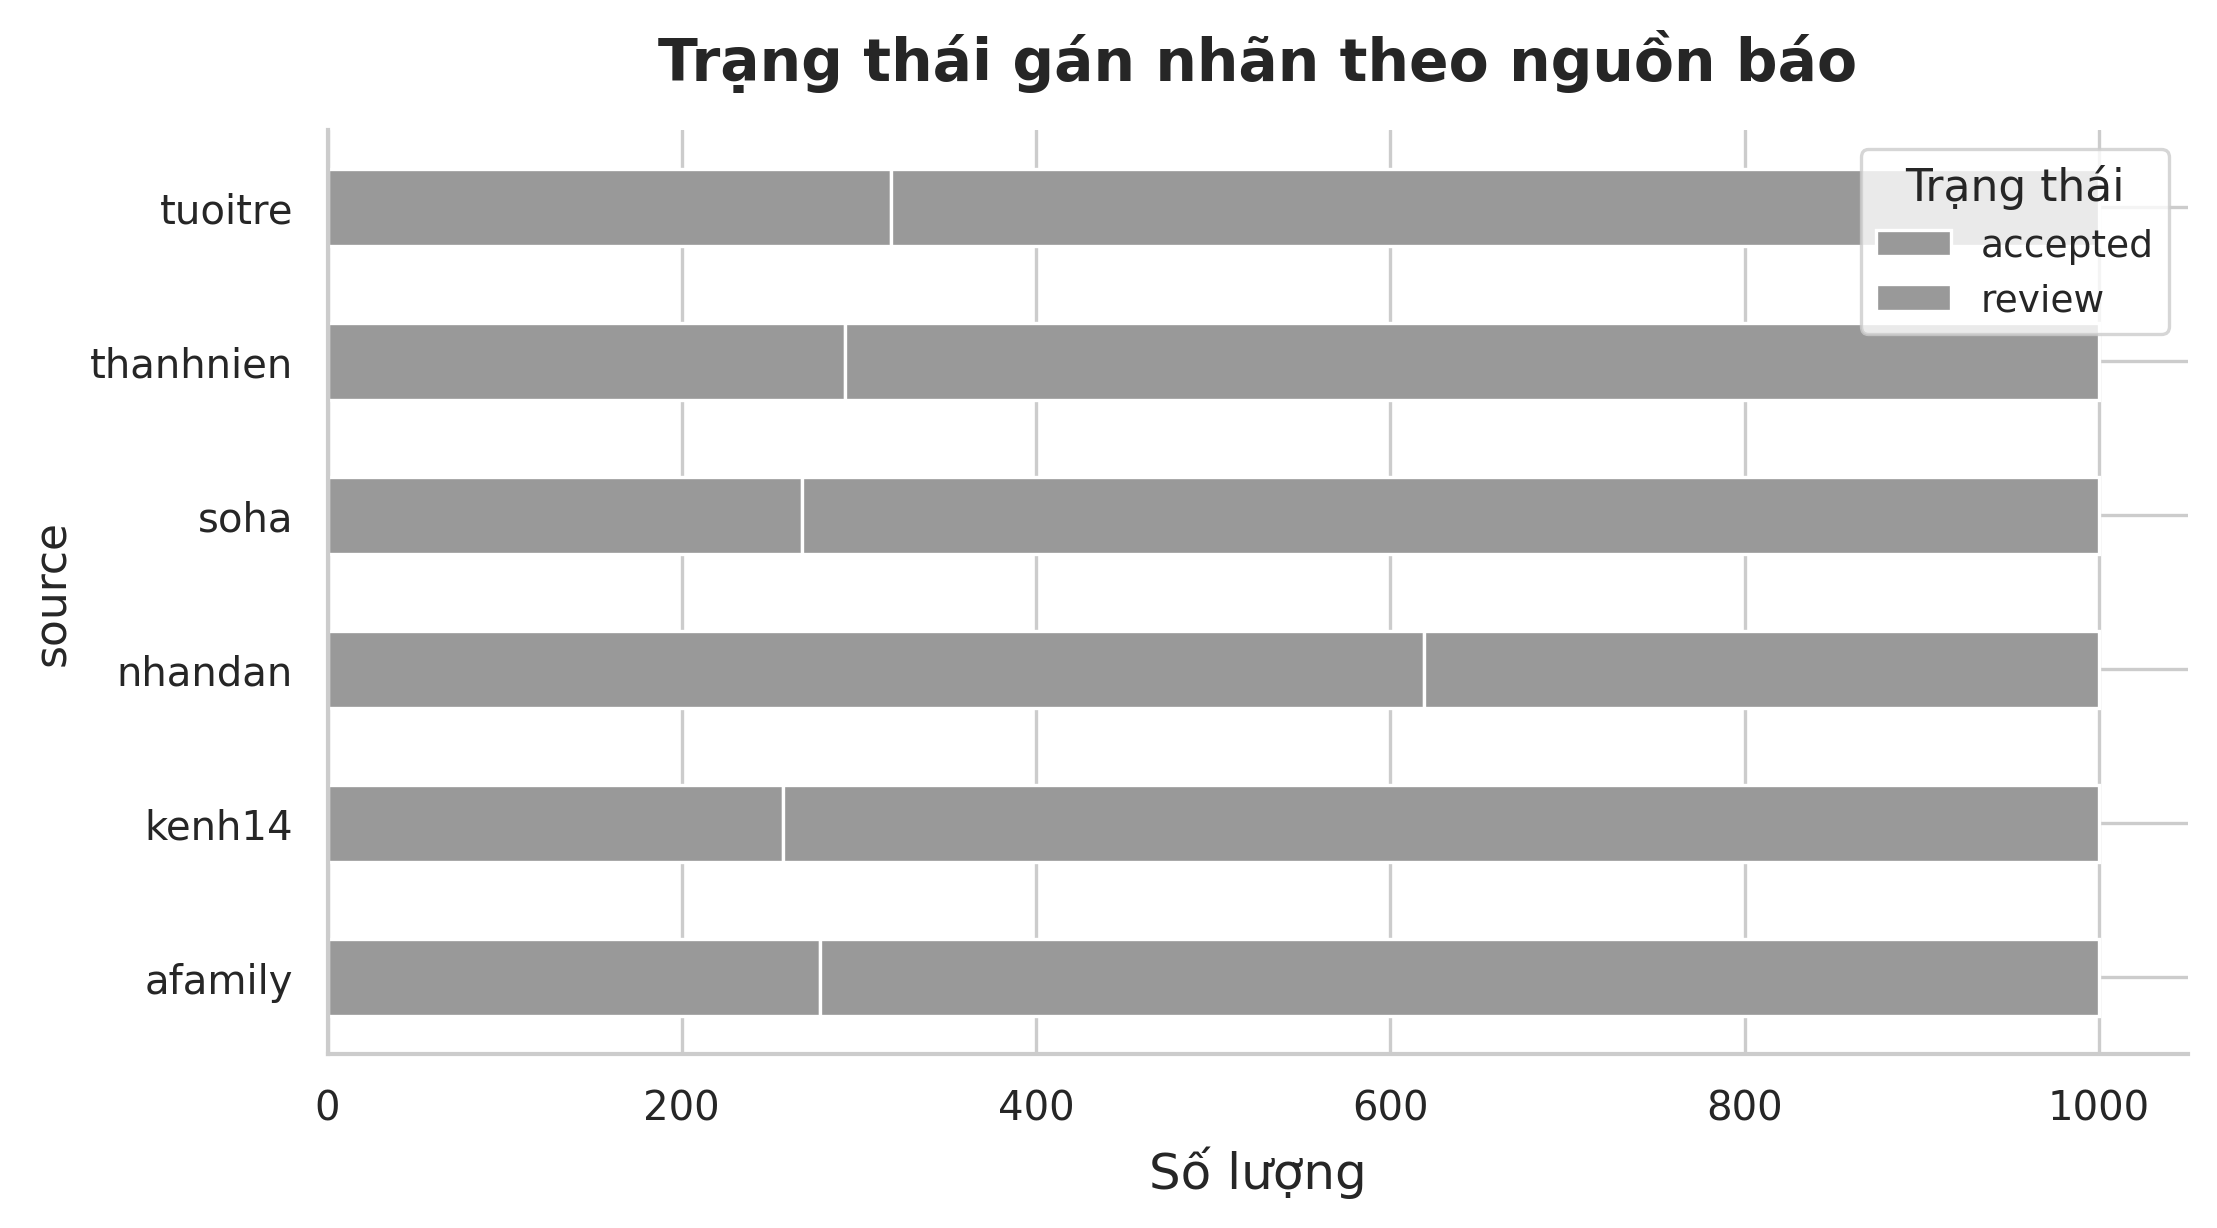

In [10]:
# Hiển thị trạng thái gán nhãn theo nguồn báo (Status Flow)
visualizer.fig_status_flow(full_df)
display(Image(filename="../docs/figures/fig_02_status_flow.png"))

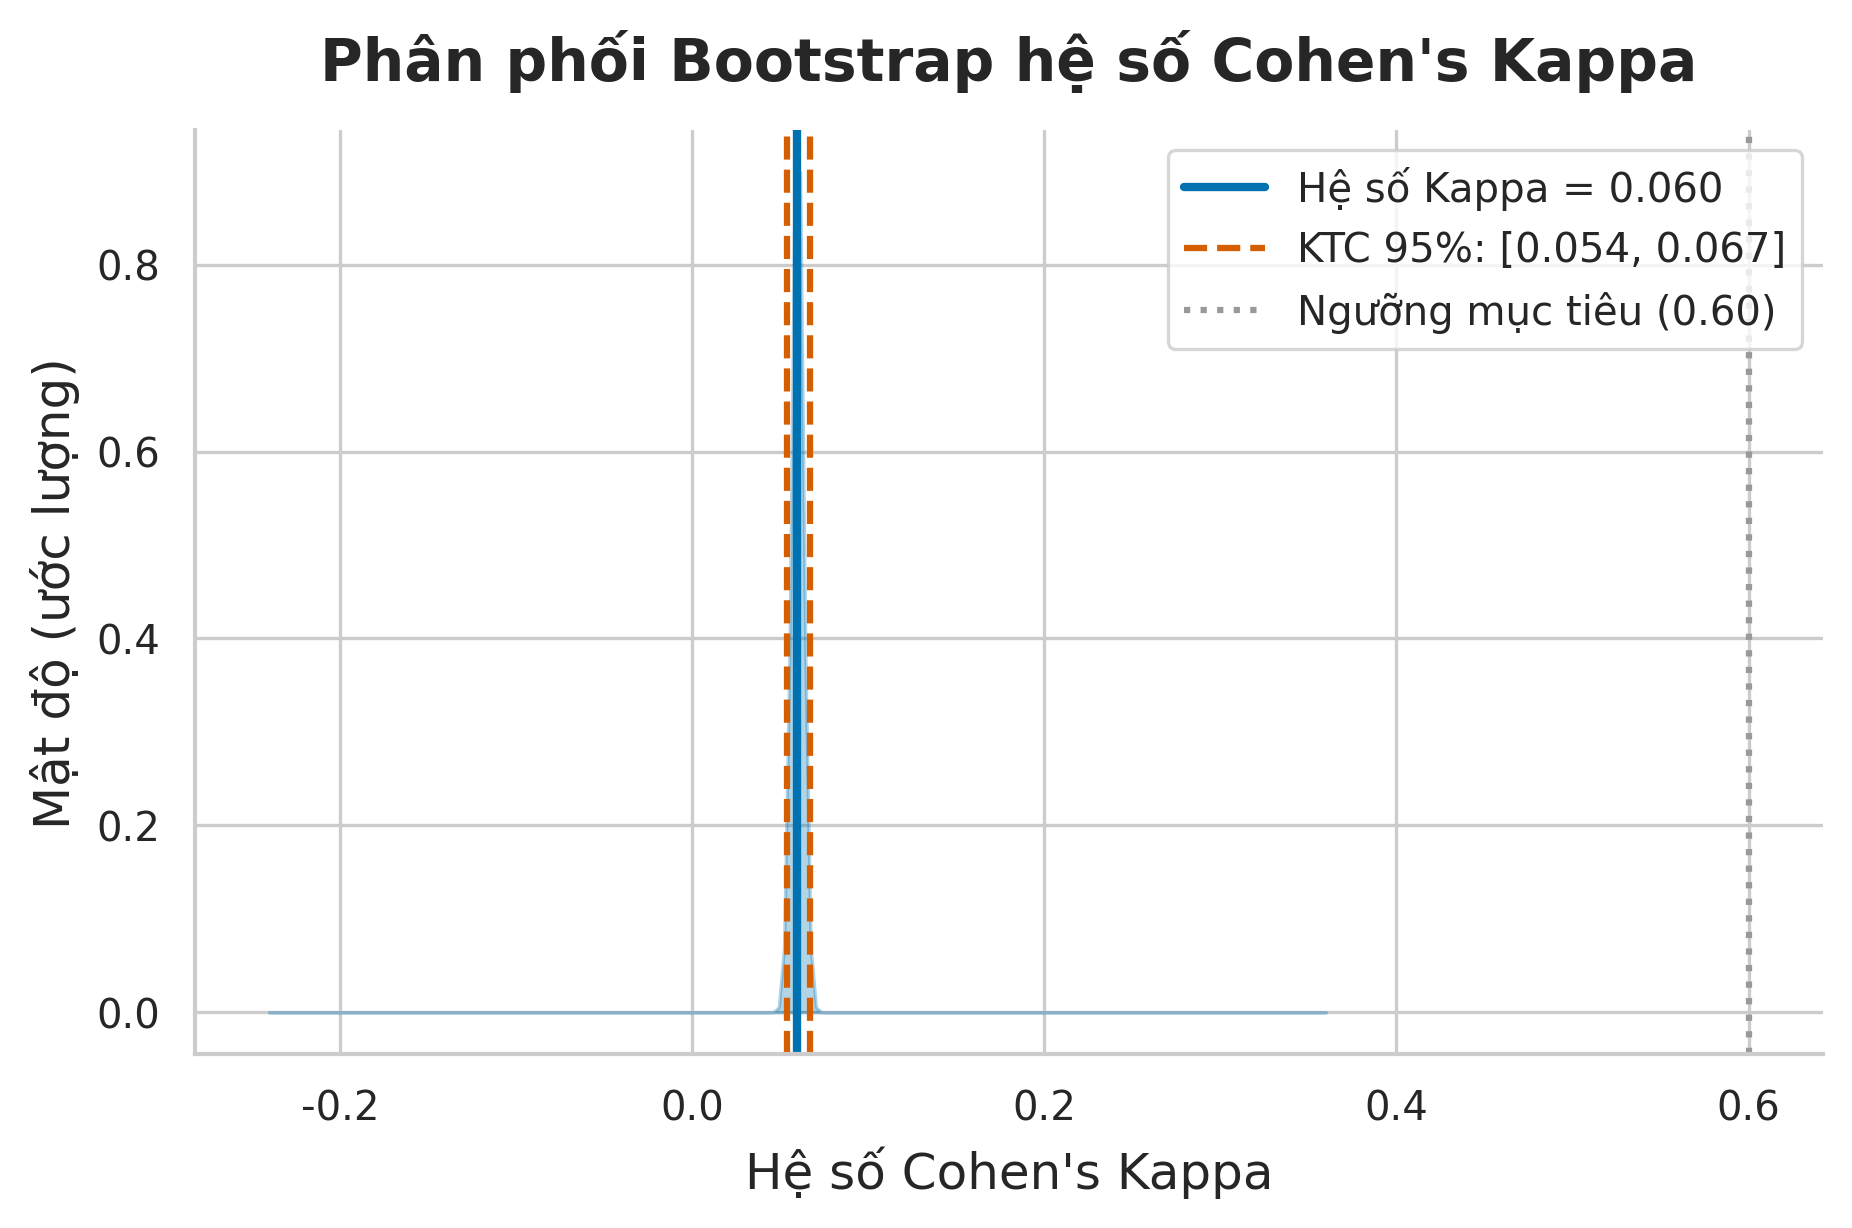

In [11]:
# Hiển thị Phân phối Bootstrap của chỉ số Kappa
visualizer.fig_bootstrap_distribution(full_df, iaa_results)
display(Image(filename="../docs/figures/fig_03_bootstrap_distribution.png"))

### Phân tích Nghịch lý Kappa và Sự bất đồng thuận giữa các LLM:

1. **Tại sao chỉ số Kappa/Fleiss' Kappa ban đầu lại rất thấp?**
   Chỉ số Cohen's Kappa giữa Qwen 2.5 3B và Gemma 2 2B chỉ đạt 0.0598. Đây là minh chứng rõ rệt của **Nghịch lý Kappa (Kappa Paradox)**:
   - Gemma 2 2B gán nhãn cực kỳ cởi mở (phân loại 74.2% là clickbait).
   - Qwen 2.5 3B gán nhãn cực kỳ khắt khe (chỉ phân loại 9.1% là clickbait).
   - Sự lệch ngưỡng quyết định quá lớn này dẫn đến việc hai mô hình bất đồng thuận trên 65.6% dữ liệu, kéo các hệ số thỏa thuận điều chỉnh ngẫu nhiên sụt giảm nghiêm trọng về sát mức 0.
2. **Giải pháp xử lý:**
   Tất cả 3.968 bản ghi có điểm biên hoặc bất đồng thuận đều được định tuyến đến kiểm duyệt viên con người để đánh giá thủ công tạo nhãn vàng (gold-standard). Do đó, sự thiếu hụt độ tin cậy ban đầu của các LLM đã được xử lý triệt để thông qua cơ chế Human-in-the-loop.

## Phần 5: Đánh giá Chất lượng Mô hình gán nhãn

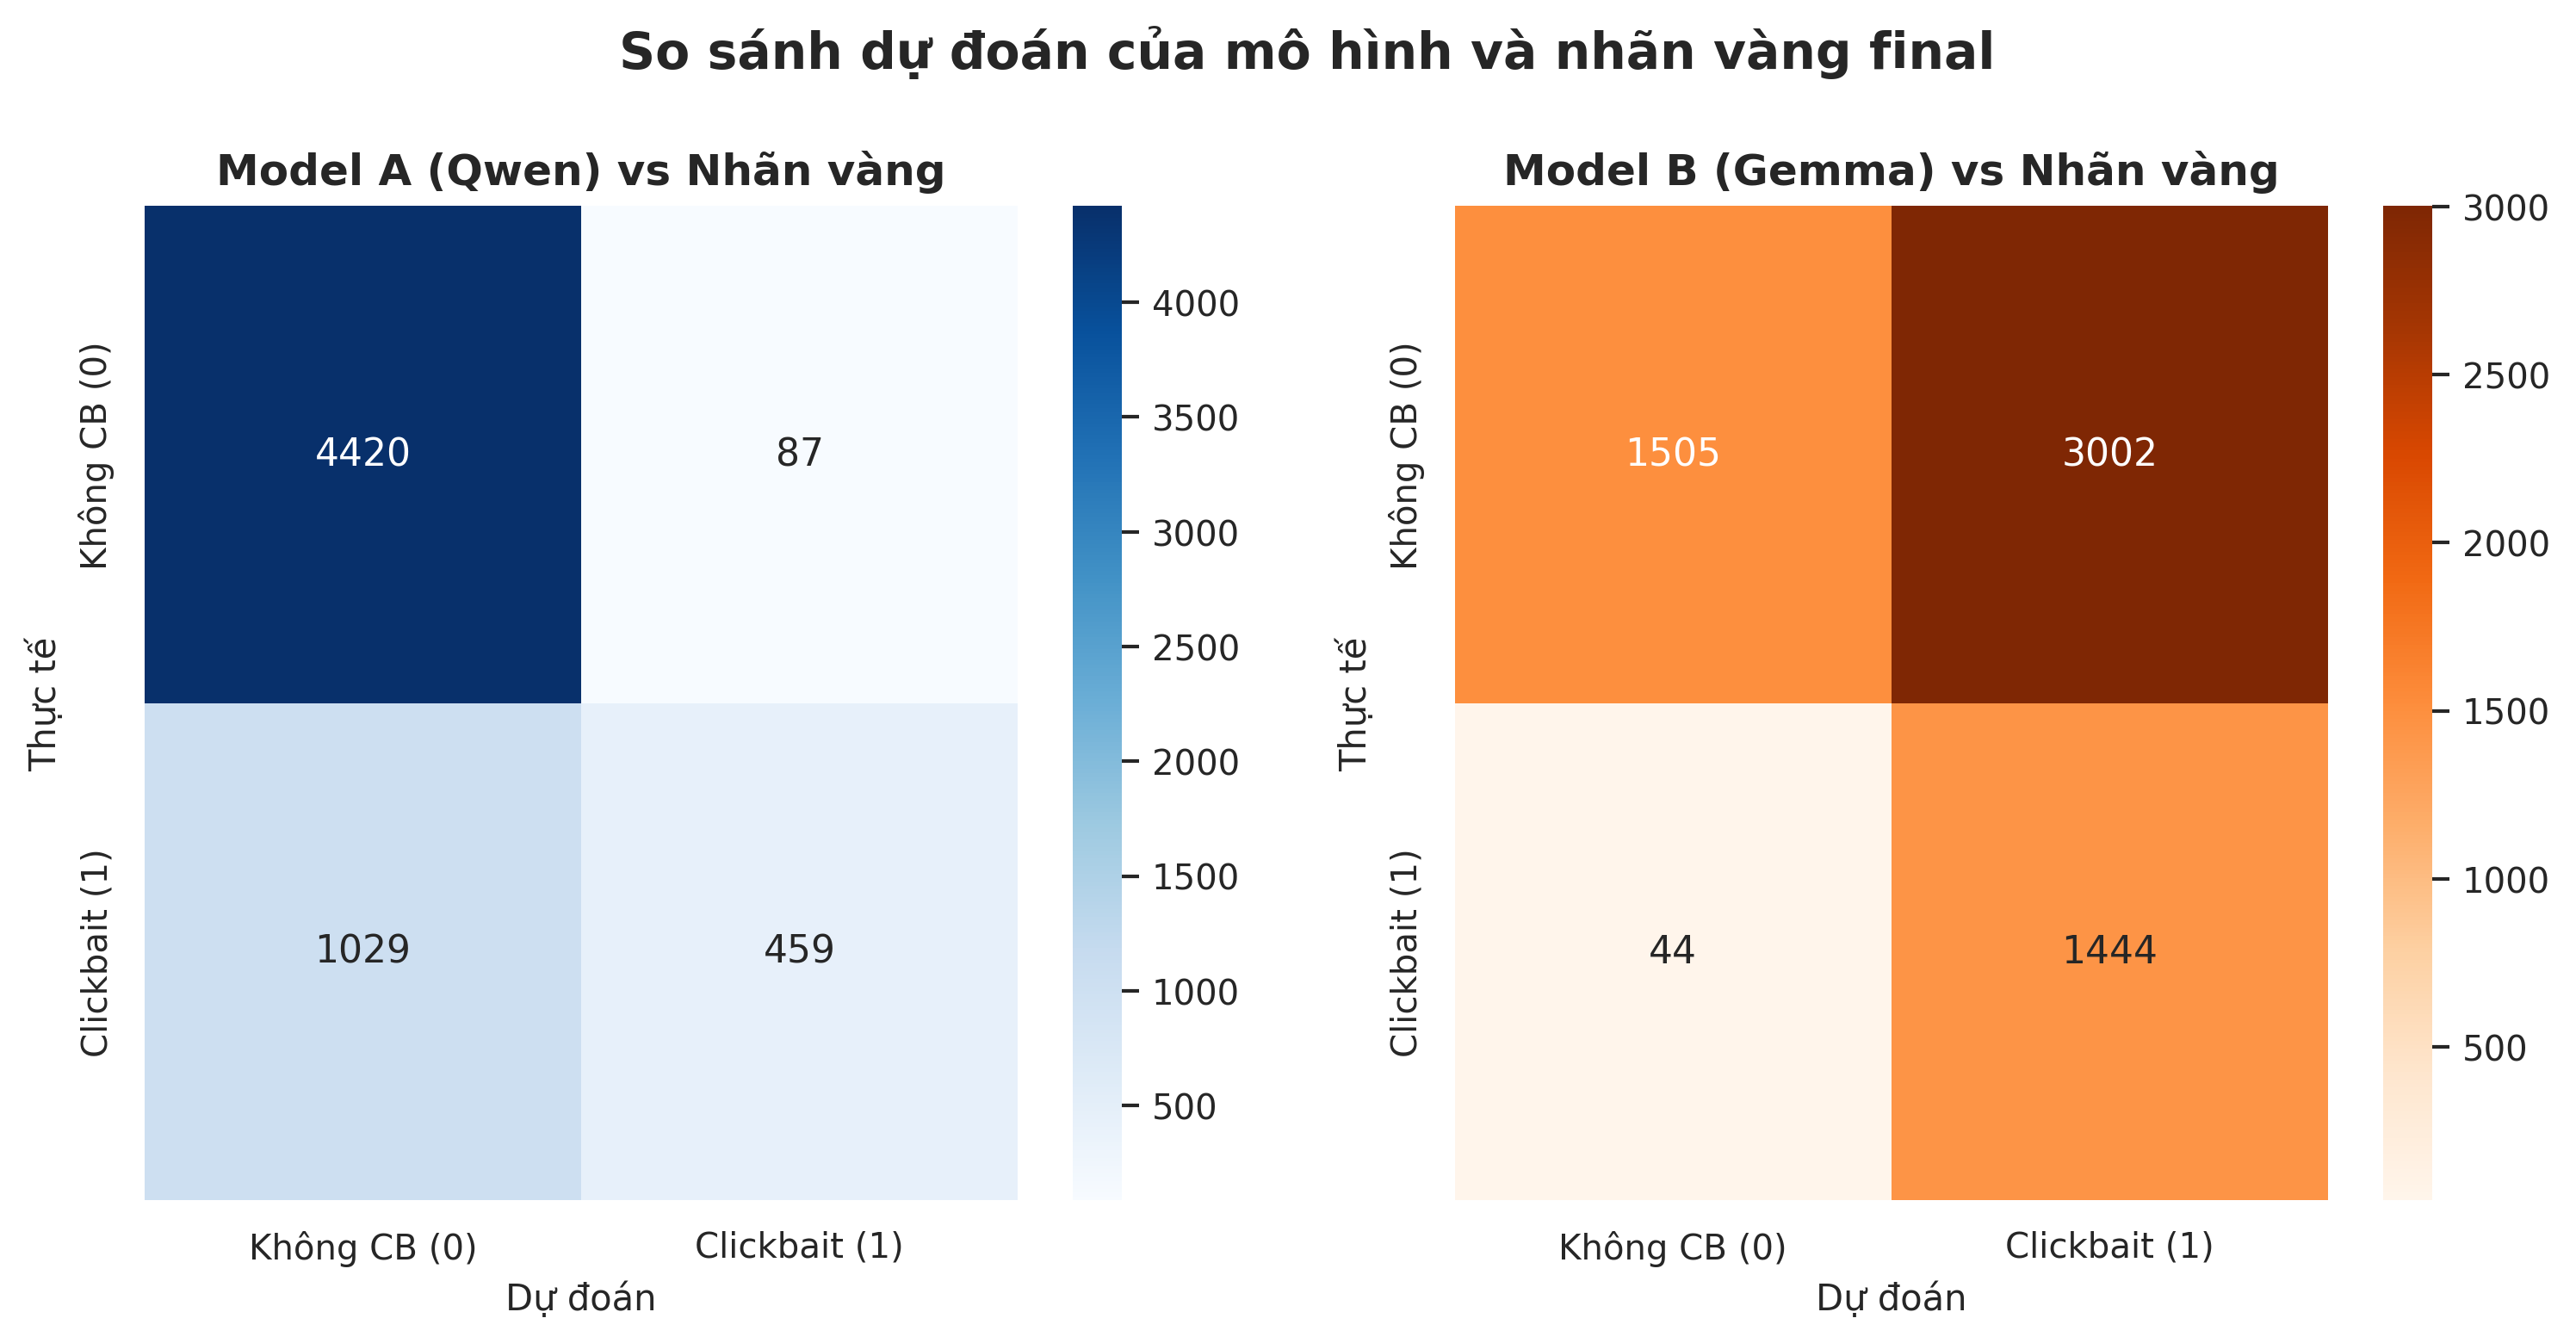

In [12]:
# Tạo và hiển thị Ma trận nhầm lẫn Model vs Nhãn cuối cùng
visualizer.fig_confusion_model_vs_final(full_df)
display(Image(filename="../docs/figures/fig_10_confusion_model_vs_final.png"))

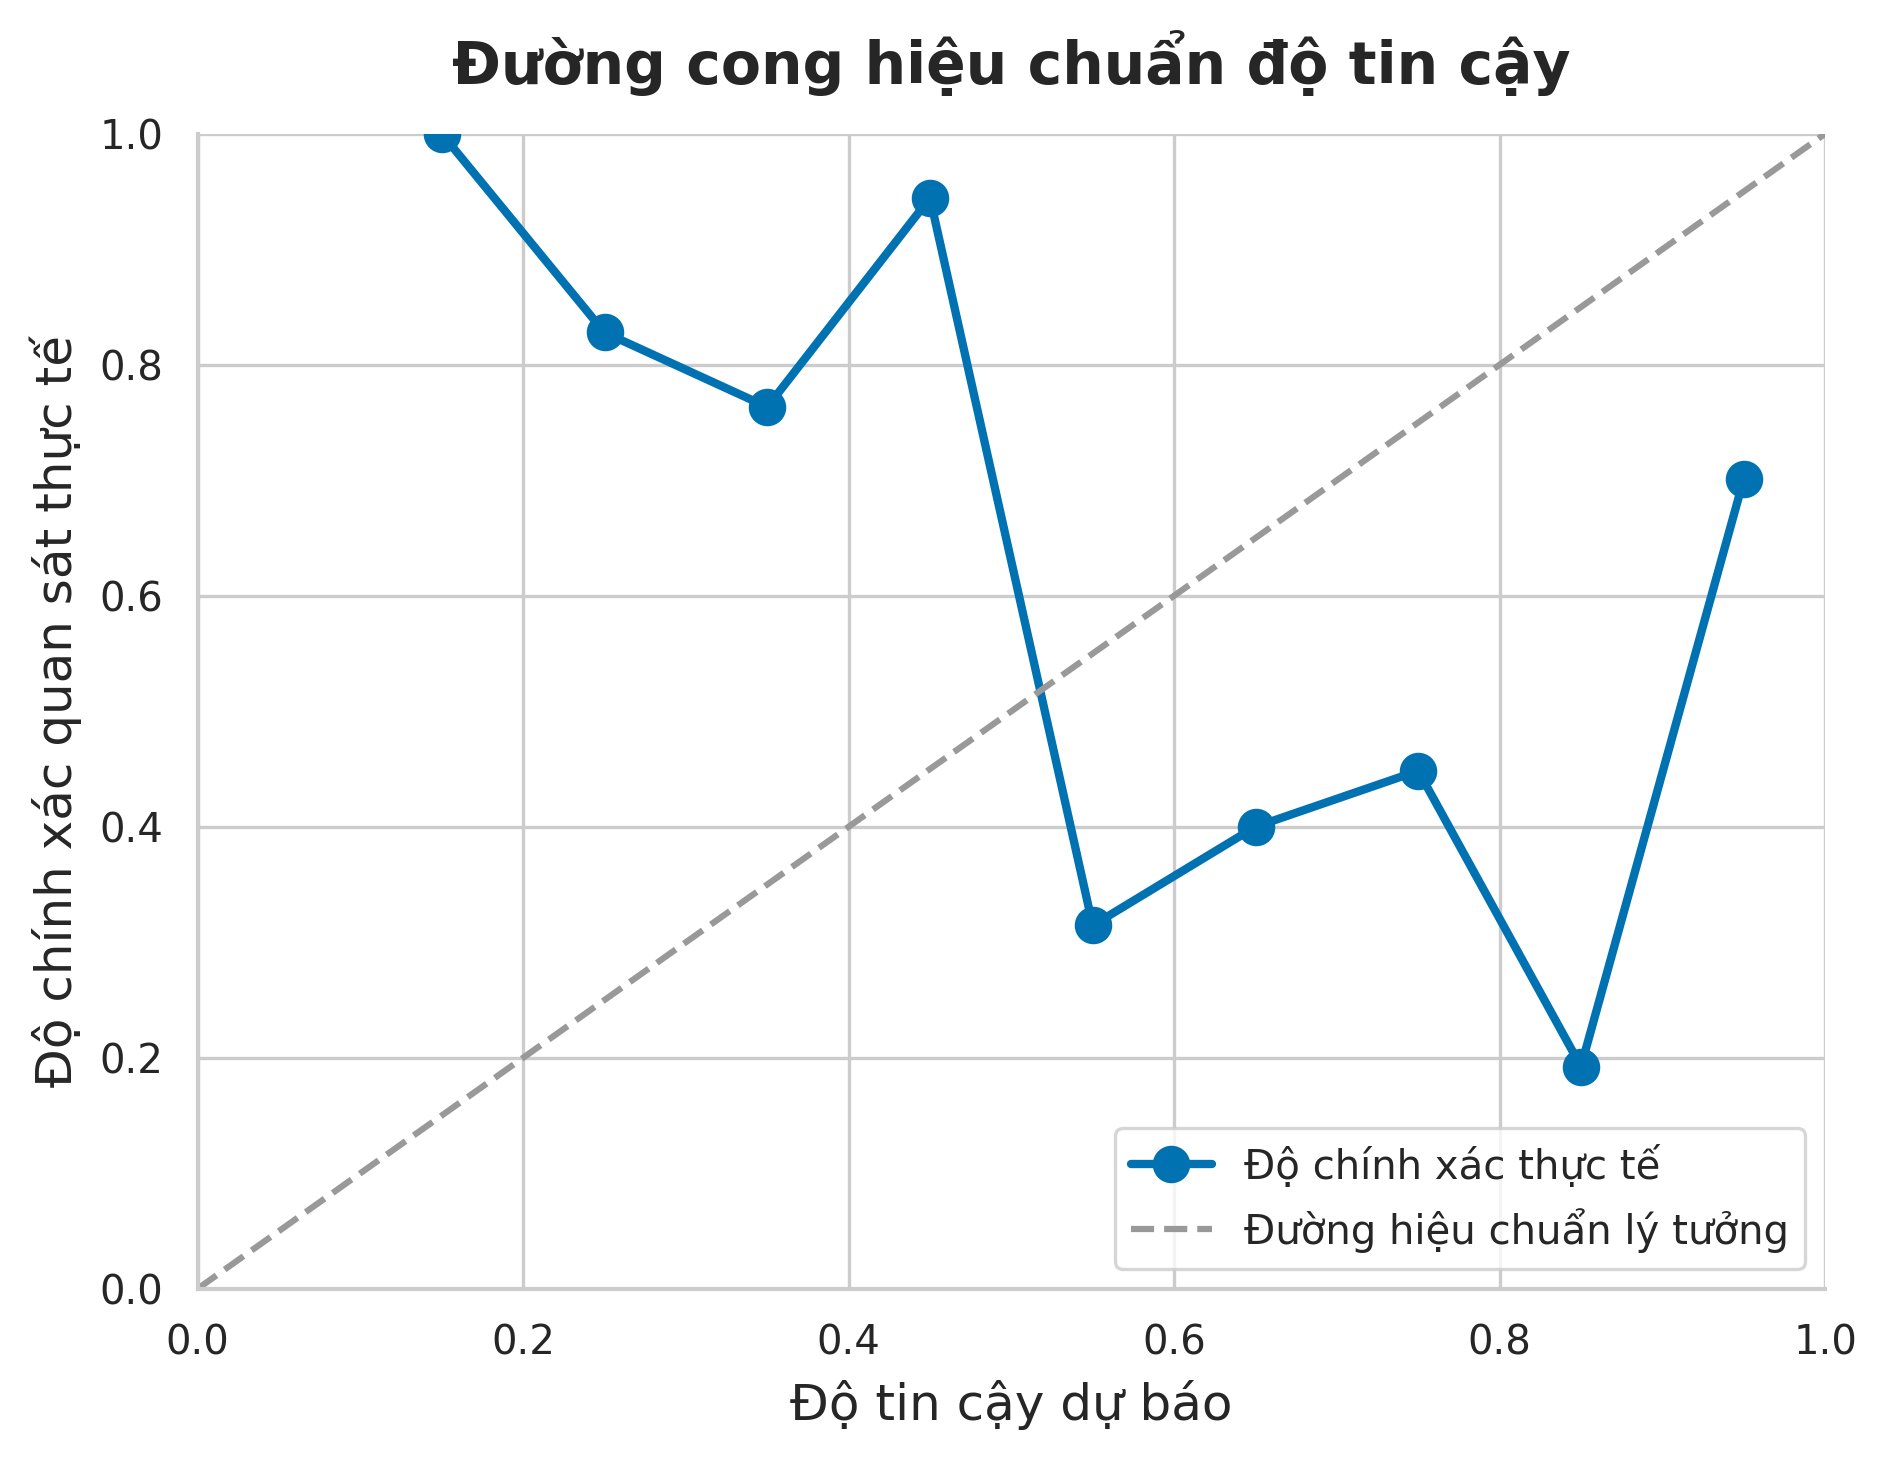

In [13]:
# Tạo và hiển thị Đường cong Hiệu chỉnh Calibration của mô hình
visualizer.fig_confidence_calibration(full_df)
display(Image(filename="../docs/figures/fig_09_confidence_calibration.png"))

### Đánh giá Độ tin cậy của Annotator bằng LLM:

- **Gemma 2 2B (Model B):** Độ phủ (recall) cao nhưng độ chính xác (precision) thấp. Mô hình này có xu hướng gán nhãn clickbait bừa bãi cho bất kỳ tiêu đề nào sử dụng câu cảm thán hoặc có cách viết hơi thu hút.
- **Qwen 2.5 3B (Model A):** Độ chính xác cao nhưng độ phủ thấp. Mô hình chỉ gán nhãn clickbait khi tiêu đề có nhiều biểu hiện gián đoạn thông tin nghiêm trọng.
- **Đường cong Calibration:** Độ lệch khỏi đường chéo lý tưởng cho thấy các LLM thường bị tự tin quá mức (overconfident) khi chúng đồng thuận, và thiếu tự tin ở các vùng biên, khẳng định tầm quan trọng của việc kiểm duyệt thủ công.

## Phần 6: Phân tích Phân chia Dữ liệu (Train/Val/Test Split)

In [14]:
# Tải tệp logs/split_stats.json để xác thực phân phối nhãn
split_stats_path = project_root / "logs" / "split_stats.json"
with open(split_stats_path, "r", encoding="utf-8") as f:
    split_stats = json.load(f)

print("Thống kê Phân chia & Sự căn chỉnh:")
print(f"  - Kích thước tập Train: {split_stats.get('train_size')} bản ghi")
print(f"  - Số lượng Clickbait tập Train: {split_stats.get('train_clickbait_count')} ({split_stats.get('train_clickbait_rate') * 100:.2f}%)")
print(f"  - Kích thước tập Test: {split_stats.get('test_size')} bản ghi")
print(f"  - Số lượng Clickbait tập Test: {split_stats.get('test_clickbait_count')} ({split_stats.get('test_clickbait_rate') * 100:.2f}%)")
print(f"  - Chỉ số Lệch pha dữ liệu (Drift): {split_stats.get('drift'):.6f}")
print(f"  - Cảnh báo Lệch pha (Drift Warning): {split_stats.get('drift_warning')}")

Thống kê Phân chia & Sự căn chỉnh:
  - Kích thước tập Train: 4212 bản ghi
  - Số lượng Clickbait tập Train: 1046 (24.83%)
  - Kích thước tập Test: 894 bản ghi
  - Số lượng Clickbait tập Test: 221 (24.72%)
  - Chỉ số Lệch pha dữ liệu (Drift): 0.001135
  - Cảnh báo Lệch pha (Drift Warning): False


### Xác thực về Stratified Temporal Split:

Trước đây, việc chia theo thời gian đơn thuần (Temporal Split) gây ra hiện tượng trôi dữ liệu nghiêm trọng (lệch pha 14.88% tỷ lệ clickbait giữa tập train và test). Bằng cách triển khai **Stratified Temporal Split**, dữ liệu được sắp xếp theo thời gian và chia nhỏ *bên trong từng nhóm nhãn*.

Kết quả thu được:
- Tỷ lệ clickbait tập Train: **24.83%**
- Tỷ lệ clickbait tập Test: **24.72%**
- Độ lệch nhãn (Drift): **0.001135**

Chỉ số lệch pha gần như bằng 0, đảm bảo mô hình huấn luyện sẽ kiểm thử chính xác mà không gặp phải rủi ro lệch phân phối nhãn, đồng thời giữ nguyên cấu trúc phân chia thời gian thực tế.

## Phần 7: Khám phá Cốt lõi & Giới hạn dữ liệu

### Top 5 Phát hiện cốt lõi:
1. **Tỷ lệ Clickbait:** Đạt ~24.8% trên tổng thể 6.000 bài viết, tạo ra một benchmark cân bằng thực tế để huấn luyện các bộ phân loại văn bản tiếng Việt.
2. **Đặc trưng ngôn ngữ học:** Tiêu đề clickbait tiếng Việt được nhận dạng đặc trưng qua độ dài chữ lớn hơn (violin plot) và tần suất sử dụng các dấu câu kích thích cảm xúc (!) cao vượt trội.
3. **Sự khác biệt của Tòa soạn:** Có sự phân cấp rõ rệt giữa báo lá cải/giải trí (Kênh14/afamily) và báo chính thống nhà nước (Nhân Dân) về tỷ lệ giật gân.
4. **Thiên lệch mô hình:** Các mô hình LLM nhỏ (<4B) có xu hướng bị lệch ngưỡng quyết định nhãn rất lớn (Gemma gán nhãn lỏng lẻo, Qwen gán nhãn nghiêm khắc).
5. **Tầm quan trọng của con người:** Hệ số tương đồng thỏa thuận Kappa giữa các mô hình máy gần bằng 0, chứng minh các pipeline tự động hóa hoàn toàn bằng AI không đáng tin cậy và bắt buộc phải kết hợp kiểm duyệt con người.

### Giới hạn dữ liệu:
- **Độ bao phủ nguồn tin:** Chỉ giới hạn ở 6 nguồn báo chính thống lớn, chưa phủ hết các bài đăng mạng xã hội vốn có mật độ clickbait phức tạp hơn.
- **Thời gian thu thập:** Thu thập trong khoảng thời gian ngắn năm 2025, có thể bỏ lỡ các biến động clickbait theo xu hướng sự kiện của năm.
- **Thiên lệch lượng tử hóa:** Mô hình LLM chạy cục bộ ở dạng lượng tử hóa 4-bit nhằm tương thích phần cứng máy tính yếu, có thể làm giảm nhẹ khả năng suy luận logic tinh tế khi phân tích ngữ cảnh tiêu đề.